URL index: [Home](https://zzz.bwh.harvard.edu/luna-walkthrough/) | [Data](https://zzz.bwh.harvard.edu/luna-walkthrough/data/) | [S1. File QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p1/) | [S2. Signal QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p2) | [S3. Staging](https://zzz.bwh.harvard.edu/luna-walkthrough/p3) | [S4. Artifacts](https://zzz.bwh.harvard.edu/luna-walkthrough/p4) | [S5. Analysis](https://zzz.bwh.harvard.edu/luna-walkthrough/p5)

Notebook index: [Index](../00_index.ipynb) | [S1. File QC](../p1/00_index.ipynb) | [S2. Signal QC](../p2/00_index.ipynb) | [S3. Staging](../p3/00_index.ipynb) | [S4. Artifacts](../p4/00_index.ipynb) | [S5. Analysis](../p5/00_index.ipynb)

---

# 5.4. Connectivity

Walkthrough URL = [https://zzz.bwh.harvard.edu/luna-walkthrough/p5/conn](https://zzz.bwh.harvard.edu/luna-walkthrough/p5/conn)

---


In [1]:
import lunapi as lp
proj = lp.proj()
proj.sample_list( '../c.lst' )

initiated lunapi v1.2.3 <lunapi.lunapi0.luna object at 0x117456230> 

read 20 individuals from ../c.lst


## Simulated signals

_(skipped in this walkthrough -- see the original [web pages](https://zzz.bwh.harvard.edu/luna-walkthrough/p5/conn/#simulated-signals))_

## Phase-slope index (PSI)

We'll apply the `PSI` command to N2 and REM sleep separately. Because PSI uses a bootstrap method to create standardized statistics, we'll select the same, fixed number of epochs per individual (50 epochs, or 25 minutes) of each stage. (Note: this randomization means that different runs will produce slightly different results, although we expect the fundamental patterns to hold.)

We'll instruct `PSI` to look at all pairwise combinations of channels; for each analysis, it will consider how connectivity changes as a function of frequency, and so the methods requires an interval spanning multiple frequency bins. We'll specify a 4 Hz window (w), initially centered on 3 Hz (f-lwr, i.e. 1 - 5 hz) which is then shifted in increments of 2 Hz (r) up to 19 Hz (f-upr, i.e. 17 - 21 Hz).

First, for N2 sleep:

In [3]:
#luna c.lst -o out/coh-nrem.db order-signals=T \
#  -s ' MASK ifnot=N2 & RE
#       CHEP-MASK ep-th=3,3
#       CHEP epochs & RE
#       MASK random=50 & RE
#       PSI sig=${eeg} f-lwr=3 f-upr=19 r=2 w=4 double-entry=F '

proj.var( 'order-signals' , 'T' ) 

res = proj.silent_proc( '''
    MASK ifnot=N2 & RE
    CHEP-MASK ep-th=3,3
    CHEP epochs & RE
    MASK random=50 & RE
    PSI sig=${eeg} f-lwr=3 f-upr=19 r=2 w=4 double-entry=F 
    ''' ) 

In [4]:
# save
nr1 = proj.table( 'PSI' , 'CH_F' ) 
nr2 = proj.table( 'PSI' , 'CH1_CH2_F' ) 
nr2

,ID,CH1,CH2,F,PSI
0,F01,AF3,AF4,3.0,0.419733
1,F02,AF3,AF4,3.0,-0.561334
2,F03,AF3,AF4,3.0,-0.424625
3,F04,AF3,AF4,3.0,-2.069466
4,F05,AF3,AF4,3.0,-3.894665
...,...,...,...,...,...
287275,M06,TP7,TP8,19.0,-1.26568
287276,M07,TP7,TP8,19.0,-0.074318
287277,M08,TP7,TP8,19.0,-1.278497
287278,M09,TP7,TP8,19.0,1.203745


In [6]:
# i.e. final F-by-CH1-by-CH2 table of pairwise stats for 57 channels at 9 frequency bins (for N=20 people)
20 * 9 * 57 * 56 / 2  

287280.0

Then for REM:

In [7]:
res = proj.silent_proc( '''
    MASK ifnot=R & RE
    CHEP-MASK ep-th=3,3
    CHEP epochs & RE
    MASK random=50 & RE
    PSI sig=${eeg} f-lwr=3 f-upr=19 r=2 w=4 double-entry=F 
    ''' ) 

r1 = proj.table( 'PSI' , 'CH_F' ) 

r2 = proj.table( 'PSI' , 'CH1_CH2_F' ) 


## net PSI

In [19]:
# nr <- read.table( "res/psi1.n2" , header=T, stringsAsFactors=F)
# r  <- read.table( "res/psi1.rem" , header=T, stringsAsFactors=F) 
# d <- nr[ , c("ID","CH","F","PSI") ]
df = nr1
df.rename(columns={'PSI': 'NR'}, inplace=True)
# *assumes* similar row ordering...
df[ 'R' ] = r1.PSI 

In [20]:
df

,ID,CH,F,NR,R
0,F01,AF3,3.0,2.038656,-6.210093
1,F02,AF3,3.0,0.493953,1.618635
2,F03,AF3,3.0,-1.700738,-3.63394
3,F04,AF3,3.0,-4.405555,0.51216
4,F05,AF3,3.0,0.716631,-3.26372
...,...,...,...,...,...
10255,M06,TP8,19.0,2.612649,-1.375676
10256,M07,TP8,19.0,-1.547205,0.554873
10257,M08,TP8,19.0,1.539561,-1.828774
10258,M09,TP8,19.0,-1.951397,0.688799


We can summarize these metrics, by channel and frequency:

In [21]:
#s.nr <- data.frame( tapply( d$NR , list( d$CH , d$F ) , mean ) )
#s.r  <- data.frame( tapply( d$R  , list( d$CH , d$F ) , mean ) )

s = df.groupby( ['CH', 'F'] )[ ['NR', 'R'] ].mean()
s

NR         R
CH  F                       
AF3 3.0  -0.681605 -2.690533
    5.0   0.967121 -5.706986
    7.0   0.327739   0.25617
    9.0  -0.263487  3.084219
    11.0 -2.595321  2.138738
...            ...       ...
TP8 11.0 -0.866087 -0.559006
    13.0 -0.481282 -0.073124
    15.0  0.718089 -0.254752
    17.0  1.275414 -0.729026
    19.0  0.646986 -0.063263

[513 rows x 2 columns]

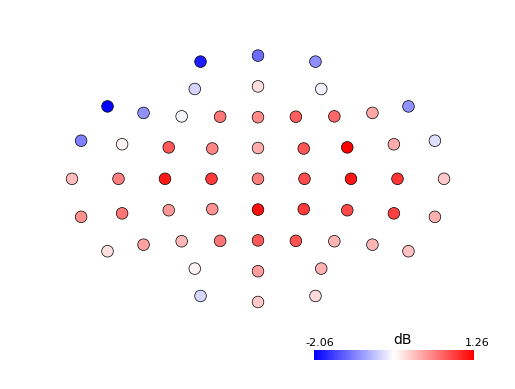

In [35]:
import numpy as np
zlim = np.nanmin([s.NR, s.R]), np.nanmax([s.NR, s.R])

xx = s.xs( 3 , level = 'F' )  

chs = xx.index.to_series()

fig, axes = plt.subplots(2, 9, figsize=(16, 4))  # Adjust figsize as needed

# Flatten axes for easy iteration
axes = axes.flatten()

for i, ax in enumerate(axes):
    x = np.linspace(0, 10, 100)
    y = np.sin(x + i)
    lp.topo_heat( chs , xx.NR ) 

    ax.plot(x, y)
    ax.set_title(f"Plot {i+1}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


### Individual-level data

_(skipped)_

## Pairwise metrics

### Visualization

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse


def eeg_1010_xy():
    def pol2cart(r, theta_deg):
        theta = np.deg2rad(theta_deg)
        return r * np.cos(theta), r * np.sin(theta)

    coords_deg = {
        'FPZ': (1.0, 90), 'AFZ': (0.92, 90), 'FZ': (0.85, 90), 'FCZ': (0.75, 90),
        'CZ': (0.6, 90), 'CPZ': (0.45, 90), 'PZ': (0.3, 90), 'POz': (0.15, 90), 'OZ': (0.0, 90),
        'Fp1': (1.0, 108), 'AF3': (0.92, 108), 'F1': (0.85, 108), 'FC1': (0.75, 108),
        'C1': (0.6, 108), 'CP1': (0.45, 108), 'P1': (0.3, 108), 'PO3': (0.15, 135),
        'Fp2': (1.0, 72), 'AF4': (0.92, 72), 'F2': (0.85, 72), 'FC2': (0.75, 72),
        'C2': (0.6, 72), 'CP2': (0.45, 72), 'P2': (0.3, 72), 'PO4': (0.15, 45),
        'F3': (0.85, 126), 'F5': (0.85, 144), 'F7': (0.85, 162),
        'FC3': (0.75, 126), 'FC5': (0.75, 144), 'FT7': (0.75, 162),
        'C3': (0.6, 126), 'C5': (0.6, 144), 'T7': (0.6, 162),
        'CP3': (0.45, 126), 'CP5': (0.45, 144), 'TP7': (0.45, 162),
        'P3': (0.3, 126), 'P5': (0.3, 144), 'P7': (0.3, 162),
        'F4': (0.85, 54), 'F6': (0.85, 36), 'F8': (0.85, 18),
        'FC4': (0.75, 54), 'FC6': (0.75, 36), 'FT8': (0.75, 18),
        'C4': (0.6, 54), 'C6': (0.6, 36), 'T8': (0.6, 18),
        'CP4': (0.45, 54), 'CP6': (0.45, 36), 'TP8': (0.45, 18),
        'P4': (0.3, 54), 'P6': (0.3, 36), 'P8': (0.3, 18),
        'O1': (0.15, 135), 'O2': (0.15, 45),
    }

    return {ch: pol2cart(r, theta) for ch, (r, theta) in coords_deg.items()}


def lremap_chs(chs):
    remap = {'T3': 'T7', 'T4': 'T8', 'T5': 'P7', 'T6': 'P8'}
    return [remap.get(ch.upper(), ch.upper()) for ch in chs]


def fshorten(x1, y1, x2, y2, p=0.05):
    dx, dy = x2 - x1, y2 - y1
    return x1 + dx * p / 2, y1 + dy * p / 2, x2 - dx * p / 2, y2 - dy * p / 2


def arconn(chs1, chs2, z, flt=None, zr=None, z2=None, z2r=None,
           cex=200, title="", head=True, dst=0.35,
           lwd1=0.5, lwd2=2, directional=False):

    ldefault_xy = eeg_1010_xy()
    chs1 = lremap_chs(chs1)
    chs2 = lremap_chs(chs2)
    all_chs = list(set(chs1 + chs2))
    xy = {ch: ldefault_xy[ch] for ch in all_chs if ch in ldefault_xy}

    if z2 is None:
        z2 = z
    if flt is None:
        flt = [True] * len(z)

    conns = []
    for c1 in all_chs:
        for c2 in all_chs:
            if c1 in xy and c2 in xy:
                d = np.sqrt((xy[c1][0] - xy[c2][0]) ** 2 + (xy[c1][1] - xy[c2][1]) ** 2)
                if d < dst:
                    conns.append((c1, c2))

    included = [
        (a, b, z[i], z2[i], flt[i])
        for i, (a, b) in enumerate(zip(chs1, chs2))
        if (a, b) in conns or (b, a) in conns
    ]

    if not included:
        return

    chs1, chs2, z, z2, flt = zip(*included)
    chs1, chs2, z, z2, flt = list(chs1), list(chs2), list(z), list(z2), list(flt)

    chs1 = [chs1[i] for i in range(len(flt)) if flt[i] and z[i] >= 0]
    chs2 = [chs2[i] for i in range(len(flt)) if flt[i] and z[i] >= 0]
    z = [z[i] for i in range(len(flt)) if flt[i] and z[i] >= 0]
    z2 = [z2[i] for i in range(len(flt)) if flt[i] and z[i] >= 0]

    if len(chs1) == 0:
        return

    if zr is None:
        zr = (min(z), max(z))
    if z2r is None:
        z2r = (min(z2), max(z2))

    z_norm = np.clip(np.round(100 * (np.array(z) - zr[0]) / (zr[1] - zr[0])), 1, 100).astype(int)
    z2_norm = np.clip(np.round(100 * (np.array(z2) - z2r[0]) / (z2r[1] - z2r[0])), 1, 100).astype(int)

    cmap = plt.get_cmap("coolwarm" if directional else "hot")
    colors = [cmap(v / 100) for v in z2_norm]

    fig, ax = plt.subplots()
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title)

    for i in range(len(chs1)):
        if chs1[i] not in xy or chs2[i] not in xy:
            continue
        x1, y1 = xy[chs1[i]]
        x2, y2 = xy[chs2[i]]
        px = fshorten(x1, y1, x2, y2, p=0.4)
        ax.annotate("",
                    xy=(px[2], px[3]), xytext=(px[0], px[1]),
                    arrowprops=dict(arrowstyle="->", color=colors[i],
                                    lw=lwd1 + lwd2 * (z_norm[i] / 100.0)))

    for ch, (x, y) in xy.items():
        ax.plot(x, y, 'o', markersize=cex / 100, color='gray')
        ax.text(x, y, ch, fontsize=8, ha='center', va='center')

    if head:
        ellipse = Ellipse((0, 0), width=2.0, height=2.0, edgecolor='darkgray', facecolor='none', lw=0.75)
        ax.add_patch(ellipse)
        ax.plot([0, -0.1], [1.1, 1.0], color='darkgray', lw=0.75)
        ax.plot([0, 0.1], [1.1, 1.0], color='darkgray', lw=0.75)

    plt.show()
    print(f"{len(chs1)} pairs, range {zr}")



In [45]:
s = nr2.groupby( ['CH1', 'CH2', 'F'] )[ 'PSI' ].mean()
t = s.xs( 13 , level = 'F' ).reset_index()

In [55]:
arconn( t.CH1 , t.CH2 , t.PSI ) 

IndexError: list index out of range

In [51]:
def eeg_1010_xy():
    """Returns (x, y) coordinates for the full 10–10 EEG system channels in polar layout."""
    import numpy as np

    def pol2cart(r, theta_deg):
        theta = np.deg2rad(theta_deg)
        return r * np.cos(theta), r * np.sin(theta)

    coords_deg = {
        # Midline
        'FPZ': (1.0, 90), 'AFZ': (0.92, 90), 'FZ': (0.85, 90), 'FCZ': (0.75, 90),
        'CZ': (0.6, 90), 'CPZ': (0.45, 90), 'PZ': (0.3, 90), 'POz': (0.15, 90), 'OZ': (0.0, 90),

        # Left hemisphere (negative angles)
        'Fp1': (1.0, 108), 'AF3': (0.92, 108), 'F1': (0.85, 108), 'FC1': (0.75, 108),
        'C1': (0.6, 108), 'CP1': (0.45, 108), 'P1': (0.3, 108), 'PO3': (0.15, 135),

        'Fp2': (1.0, 72), 'AF4': (0.92, 72), 'F2': (0.85, 72), 'FC2': (0.75, 72),
        'C2': (0.6, 72), 'CP2': (0.45, 72), 'P2': (0.3, 72), 'PO4': (0.15, 45),

        # Lateral pairs
        'F3': (0.85, 126), 'F5': (0.85, 144), 'F7': (0.85, 162),
        'FC3': (0.75, 126), 'FC5': (0.75, 144), 'FT7': (0.75, 162),
        'C3': (0.6, 126), 'C5': (0.6, 144), 'T7': (0.6, 162),
        'CP3': (0.45, 126), 'CP5': (0.45, 144), 'TP7': (0.45, 162),
        'P3': (0.3, 126), 'P5': (0.3, 144), 'P7': (0.3, 162),

        'F4': (0.85, 54), 'F6': (0.85, 36), 'F8': (0.85, 18),
        'FC4': (0.75, 54), 'FC6': (0.75, 36), 'FT8': (0.75, 18),
        'C4': (0.6, 54), 'C6': (0.6, 36), 'T8': (0.6, 18),
        'CP4': (0.45, 54), 'CP6': (0.45, 36), 'TP8': (0.45, 18),
        'P4': (0.3, 54), 'P6': (0.3, 36), 'P8': (0.3, 18),

        'O1': (0.15, 135), 'O2': (0.15, 45),
    }

    # Convert polar to Cartesian
    coords = {ch: pol2cart(r, theta) for ch, (r, theta) in coords_deg.items()}
    return coords


In [50]:
t.CH2.unique()


array(['AF4', 'AFZ', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'CP1', 'CP2',
       'CP3', 'CP4', 'CP5', 'CP6', 'CPZ', 'CZ', 'F1', 'F2', 'F3', 'F4',
       'F5', 'F6', 'F7', 'F8', 'FC1', 'FC2', 'FC3', 'FC4', 'FC5', 'FC6',
       'FCZ', 'FPZ', 'FT7', 'FT8', 'FZ', 'Fp1', 'Fp2', 'O1', 'O2', 'OZ',
       'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'PO3', 'PO4',
       'POz', 'PZ', 'T7', 'T8', 'TP7', 'TP8'], dtype=object)

### Group means

### Directional plots

### Individual-level plots

### N2-REM differences

### Sex differences

## Summary